In [1]:
# === 1) БАЗОВІ ПАКЕТИ ТА PYTORCH (CUDA 12.1) ===
%pip install --upgrade pip wheel setuptools

# PyTorch з підтримкою CUDA (під твій драйвер CUDA 12.9 сумісно з cu129)
%pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129

# Корисні бібліотеки для ноутбука і нашого пайплайна
%pip install numpy pillow matplotlib opencv-python "albumentations>=2.0.0,<3.0" tqdm ipywidgets kaggle

# Спроба поставити готове колесо pycocotools
%pip install pycocotools
%pip install pandas matplotlib numpy seaborn jupyterlab notebook ipywidgets

# === 2) FALLBACK: якщо pycocotools не імпортується, збираємо з джерел ===
import importlib, sys, subprocess
try:
    importlib.import_module("pycocotools")
except Exception as e:
    print("pycocotools wheel недоступний для цієї версії Python. Ставимо з джерел…")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cython"])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI"
    ])
try:
    import sys, subprocess
    subprocess.run(
        [sys.executable, "-m", "jupyter", "nbextension", "enable", "--py", "widgetsnbextension", "--sys-prefix"],
        check=False
    )
except Exception:
    pass




Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu129
  Using cached https://download.pytorch.org/whl/cu129/torch-2.8.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cu129/torchvision-0.23.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu129/torchaudio-2.8.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (7.4 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached h

In [2]:
# === 3) ШВИДКА ПЕРЕВІРКА СЕРЕДОВИЩА ===
import torch, albumentations as A, numpy as np, cv2, PIL, matplotlib
print("torch:", torch.__version__, "| CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("torchvision:", __import__("torchvision").__version__)
print("albumentations:", A.__version__)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("matplotlib:", matplotlib.__version__)

torch: 2.8.0+cu129 | CUDA available?: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
torchvision: 0.23.0+cu129
albumentations: 2.0.8
numpy: 2.1.2
opencv: 4.12.0
Pillow: 11.0.0
matplotlib: 3.10.6


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # швидші kernels для стабільного розміру
print("Train on:", device)

Train on: cuda


In [4]:
import json
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter, defaultdict
import cv2
from tqdm.auto import tqdm
import pandas as pd

# Налаштування відображення
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [5]:
class COCODataset(Dataset):
    def __init__(self, root_dir, annotation_file, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images
            annotation_file (string): Path to the COCO annotation file
            transform (callable, optional): Optional transform to be applied on images
        """
        self.root_dir = root_dir
        self.transform = transform
        
        # Load annotations
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create dictionaries for quick lookup
        self.images = {img['id']: img for img in self.coco_data['images']}
        self.categories = {cat['id']: cat for cat in self.coco_data['categories']}
        
        # Group annotations by image_id for faster access
        self.image_annotations = defaultdict(list)
        for ann in self.coco_data['annotations']:
            self.image_annotations[ann['image_id']].append(ann)
        
        # List of all image ids to use for indexing
        self.image_ids = list(self.images.keys())
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        """Return image and its annotations"""
        image_id = self.image_ids[idx]
        img_info = self.images[image_id]
        file_name = img_info['file_name']
        
        # Load image
        img_path = os.path.join(self.root_dir, file_name)
        image = Image.open(img_path).convert('RGB')
        
        # Get annotations for this image
        annotations = self.image_annotations[image_id]
        
        # Extract bounding boxes, class labels, and segmentation masks
        boxes = []
        labels = []
        areas = []
        segmentations = []
        iscrowd = []
        
        for ann in annotations:
            boxes.append(ann['bbox'])  # [x, y, width, height]
            labels.append(ann['category_id'])
            areas.append(ann['area'])
            segmentations.append(ann['segmentation'])
            iscrowd.append(ann['iscrowd'])
        
        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        
        # Prepare target dict
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': areas,
            'iscrowd': iscrowd,
            'segmentations': segmentations
        }
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, target
    
    def get_img_info(self, idx):
        """Get image info by index"""
        image_id = self.image_ids[idx]
        return self.images[image_id]
    
    def get_category_name(self, label_idx: int) -> str:
        """label_idx: 1..K; повертає назву категорії."""
        coco_id = self.idx_to_cat_id[int(label_idx)]
        return self.categories[coco_id]['name']

    
    def get_category_info(self):
        """Get all category information"""
        return self.categories
    
    def num_classes(self) -> int:
        return len(self.cat_ids) + 1  # з урахуванням background=0
    
    def remap_pred_labels_to_coco(self, labels_idx: np.ndarray) -> np.ndarray:
        """labels_idx: масив 1..K → повертає COCO category_id того ж розміру."""
        return np.array([self.idx_to_cat_id[int(i)] for i in labels_idx], dtype=np.int64)
    
    def category_mapping(self) -> dict:
        """Зручно для логів/звіту."""
        return {i: {'coco_id': self.idx_to_cat_id[i], 
                    'name': self.categories[self.idx_to_cat_id[i]]['name']}
                for i in range(1, len(self.cat_ids)+1)}


In [6]:
# Define dataset paths - adjust these to your file locations
COCO_ROOT = '../coco2017'
TRAIN_ROOT = os.path.join(COCO_ROOT, 'train2017')
VAL_ROOT = os.path.join(COCO_ROOT, 'val2017')
TRAIN_ANNOTATION = os.path.join(COCO_ROOT, 'annotations', 'instances_train2017.json')
VAL_ANNOTATION = os.path.join(COCO_ROOT, 'annotations', 'instances_val2017.json')

# Check if the files exist
if not os.path.exists(TRAIN_ROOT):
    print(f"Warning: {TRAIN_ROOT} directory not found!")
if not os.path.exists(VAL_ROOT):
    print(f"Warning: {VAL_ROOT} directory not found!")
if not os.path.exists(TRAIN_ANNOTATION):
    print(f"Warning: {TRAIN_ANNOTATION} file not found!")
if not os.path.exists(VAL_ANNOTATION):
    print(f"Warning: {VAL_ANNOTATION} file not found!")

# Initialize datasets
try:
    train_dataset = COCODataset(TRAIN_ROOT, TRAIN_ANNOTATION)
    val_dataset = COCODataset(VAL_ROOT, VAL_ANNOTATION)
    print(f"Training dataset size: {len(train_dataset)} images")
    print(f"Validation dataset size: {len(val_dataset)} images")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Attempting to load just annotation files for analysis...")
    with open(TRAIN_ANNOTATION, 'r') as f:
        train_data = json.load(f)
    with open(VAL_ANNOTATION, 'r') as f:
        val_data = json.load(f)
        
        
def segmentation_format_stats(data):
    """
    Повертає статистику по полям 'segmentation':
    - total_annotations: загальна к-сть анотацій
    - with_seg: к-сть анотацій з масками
    - poly / rle: к-сть полігональних / RLE масок
    - відсоткові частки
    """
    anns = data['annotations']
    n = len(anns)
    has_seg = 0
    poly = 0
    rle = 0
    for a in anns:
        seg = a.get('segmentation', None)
        if not seg:
            continue
        has_seg += 1
        # RLE — це dict з ключем 'counts'; полігони — список координат
        if isinstance(seg, dict) and 'counts' in seg:
            rle += 1
        else:
            poly += 1

    return {
        'total_annotations': n,
        'with_seg': has_seg,
        'poly': poly,
        'rle': rle,
        'with_seg_pct': round(100.0 * has_seg / n, 2) if n else 0.0,
        'poly_pct_of_seg': round(100.0 * poly / has_seg, 2) if has_seg else 0.0,
        'rle_pct_of_seg': round(100.0 * rle / has_seg, 2) if has_seg else 0.0
    }

# Виклик для train/val:
try:
    seg_train = segmentation_format_stats(train_data)
except NameError:
    seg_train = segmentation_format_stats(train_dataset.coco_data)

try:
    seg_val = segmentation_format_stats(val_data)
except NameError:
    seg_val = segmentation_format_stats(val_dataset.coco_data)

print("Train segmentation stats:", seg_train)
print("Val segmentation stats:  ", seg_val)
        

Training dataset size: 118287 images
Validation dataset size: 5000 images
Train segmentation stats: {'total_annotations': 860001, 'with_seg': 860001, 'poly': 849949, 'rle': 10052, 'with_seg_pct': 100.0, 'poly_pct_of_seg': 98.83, 'rle_pct_of_seg': 1.17}
Val segmentation stats:   {'total_annotations': 36781, 'with_seg': 36781, 'poly': 36335, 'rle': 446, 'with_seg_pct': 100.0, 'poly_pct_of_seg': 98.79, 'rle_pct_of_seg': 1.21}


In [7]:
# Function to analyze a COCO dataset from annotations
def analyze_coco_dataset(data, name="Dataset"):
    print(f"=== {name} Analysis ===")
    
    # Basic counts
    n_images = len(data['images'])
    n_annotations = len(data['annotations'])
    n_categories = len(data['categories'])
    
    print(f"Number of images: {n_images}")
    print(f"Number of annotations: {n_annotations}")
    print(f"Number of categories: {n_categories}")
    print(f"Average annotations per image: {n_annotations / n_images:.2f}")
    
    # Get all category names
    categories = {cat['id']: cat['name'] for cat in data['categories']}
    supercategories = {cat['id']: cat['supercategory'] for cat in data['categories']}
    
    # Count annotations per category
    category_counts = Counter([ann['category_id'] for ann in data['annotations']])
    
    # Create a DataFrame for better visualization
    categories_df = pd.DataFrame({
        'category_id': list(categories.keys()),
        'name': list(categories.values()),
        'supercategory': [supercategories[cat_id] for cat_id in categories.keys()],
        'count': [category_counts.get(cat_id, 0) for cat_id in categories.keys()]
    })
    
    categories_df = categories_df.sort_values('count', ascending=False)
    
    # Display top 10 categories
    print("\nTop 10 most common categories:")
    print(categories_df.head(10)[['name', 'supercategory', 'count']])
    
    # Group by supercategory
    supercategory_counts = categories_df.groupby('supercategory').agg({'count': 'sum'})
    supercategory_counts = supercategory_counts.sort_values('count', ascending=False)
    
    print("\nAnnotations per supercategory:")
    print(supercategory_counts.head(10))
    
    return categories_df, supercategory_counts

# Analyze datasets
train_categories_df, train_supercategories = analyze_coco_dataset(train_dataset.coco_data, "Training Dataset")
val_categories_df, val_supercategories = analyze_coco_dataset(val_dataset.coco_data, "Validation Dataset")
    
    
    

=== Training Dataset Analysis ===
Number of images: 118287
Number of annotations: 860001
Number of categories: 80
Average annotations per image: 7.27

Top 10 most common categories:
             name supercategory   count
0          person        person  262465
2             car       vehicle   43867
56          chair     furniture   38491
73           book        indoor   24715
39         bottle       kitchen   24342
41            cup       kitchen   20650
60   dining table     furniture   15714
45           bowl       kitchen   14358
9   traffic light       outdoor   12884
26        handbag     accessory   12354

Annotations per supercategory:
                count
supercategory        
person         262465
vehicle         96212
kitchen         86677
furniture       76985
food            63512
animal          62566
sports          50940
indoor          46088
accessory       45193
electronic      28029
=== Validation Dataset Analysis ===
Number of images: 5000
Number of annotations: 

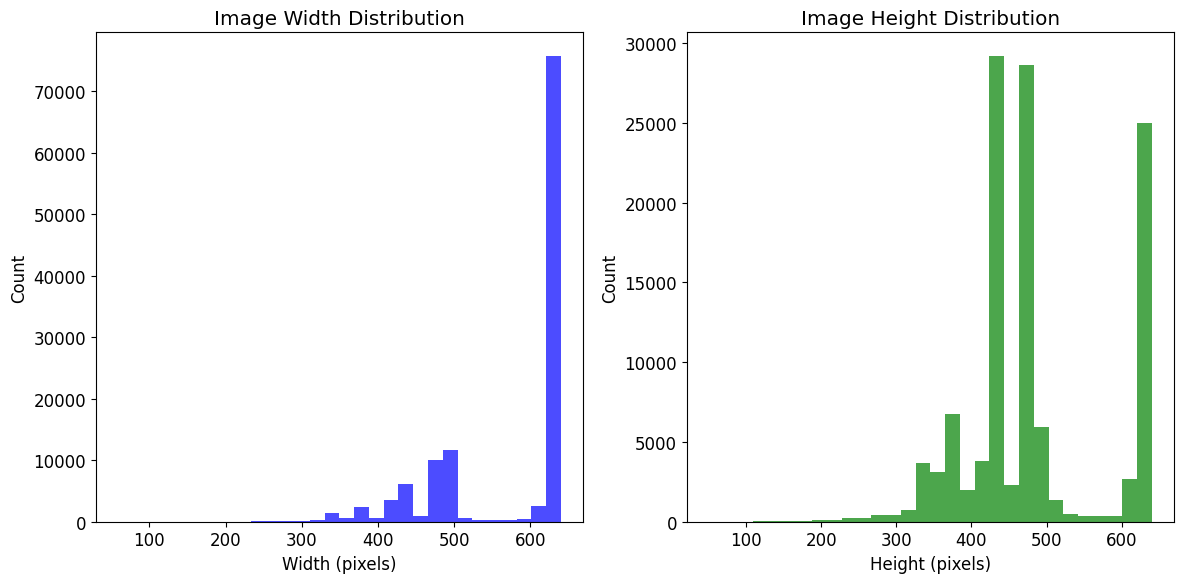

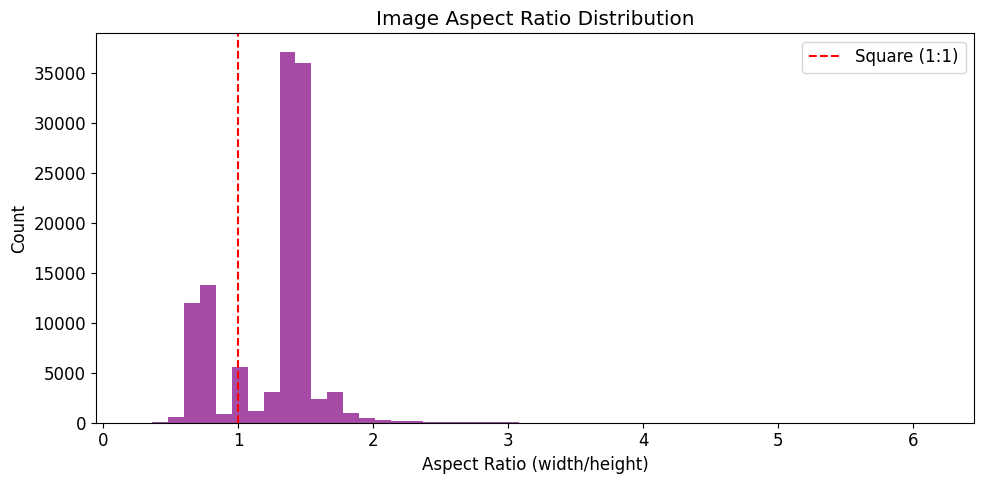

Mean image dimensions: 577.7 x 484.1 pixels
Median image dimensions: 640.0 x 480.0 pixels
Min image dimensions: 59 x 51 pixels
Max image dimensions: 640 x 640 pixels


In [8]:
# Analyze image dimensions
def analyze_image_dimensions(data):
    widths = [img['width'] for img in data['images']]
    heights = [img['height'] for img in data['images']]
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=30, alpha=0.7, color='blue')
    plt.title('Image Width Distribution')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=30, alpha=0.7, color='green')
    plt.title('Image Height Distribution')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate aspect ratios
    aspect_ratios = [w/h for w, h in zip(widths, heights)]
    
    plt.figure(figsize=(10, 5))
    plt.hist(aspect_ratios, bins=50, alpha=0.7, color='purple')
    plt.title('Image Aspect Ratio Distribution')
    plt.xlabel('Aspect Ratio (width/height)')
    plt.ylabel('Count')
    plt.axvline(x=1.0, color='red', linestyle='--', label='Square (1:1)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Mean image dimensions: {np.mean(widths):.1f} x {np.mean(heights):.1f} pixels")
    print(f"Median image dimensions: {np.median(widths):.1f} x {np.median(heights):.1f} pixels")
    print(f"Min image dimensions: {np.min(widths)} x {np.min(heights)} pixels")
    print(f"Max image dimensions: {np.max(widths)} x {np.max(heights)} pixels")

try:
    analyze_image_dimensions(train_data)
except:
    analyze_image_dimensions(train_dataset.coco_data)

C:\Users\dazap\AppData\Local\Temp\ipykernel_7436\3656641363.py:49: RuntimeWarning: divide by zero encountered in divide
  aspect_ratios = widths / heights


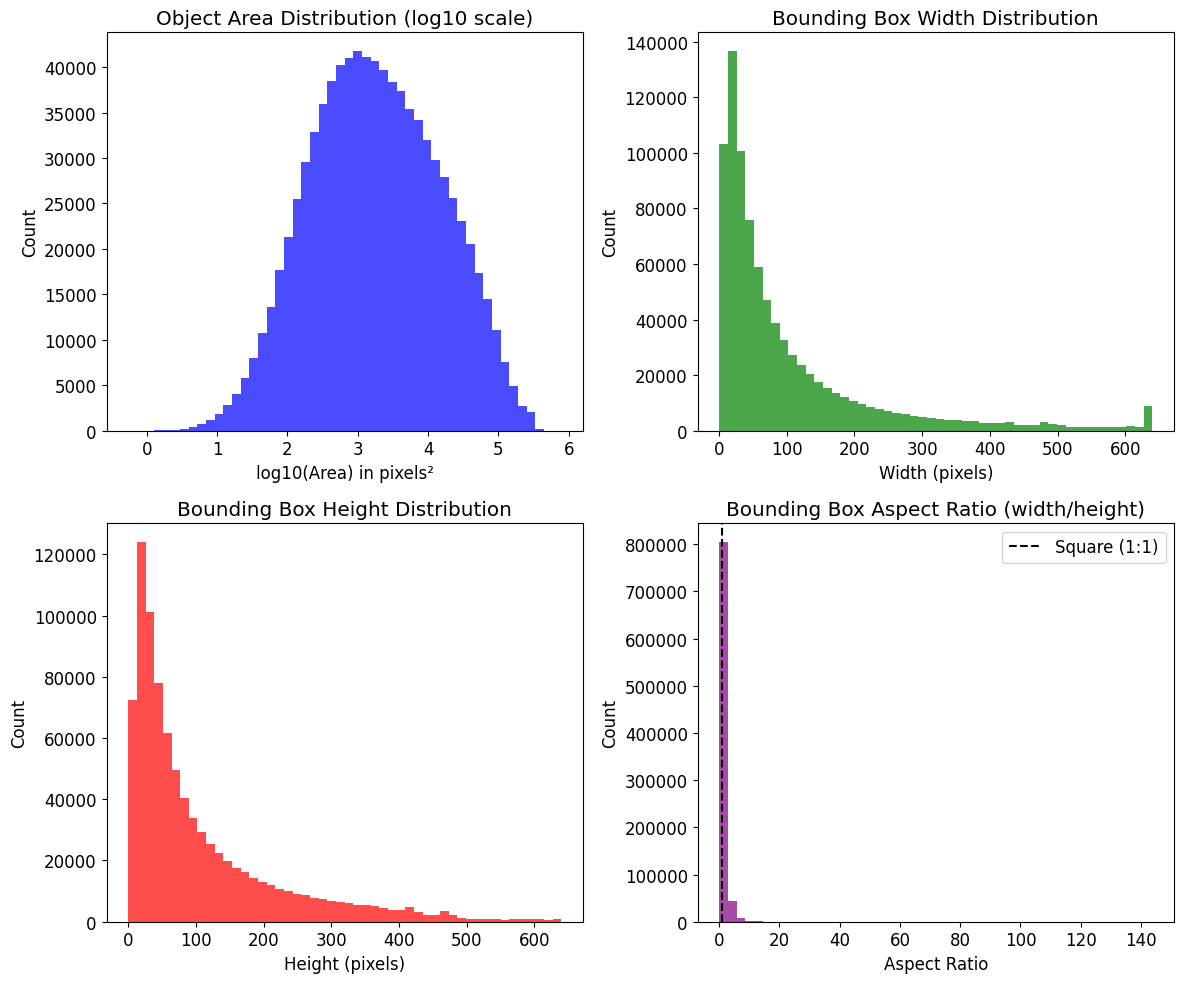

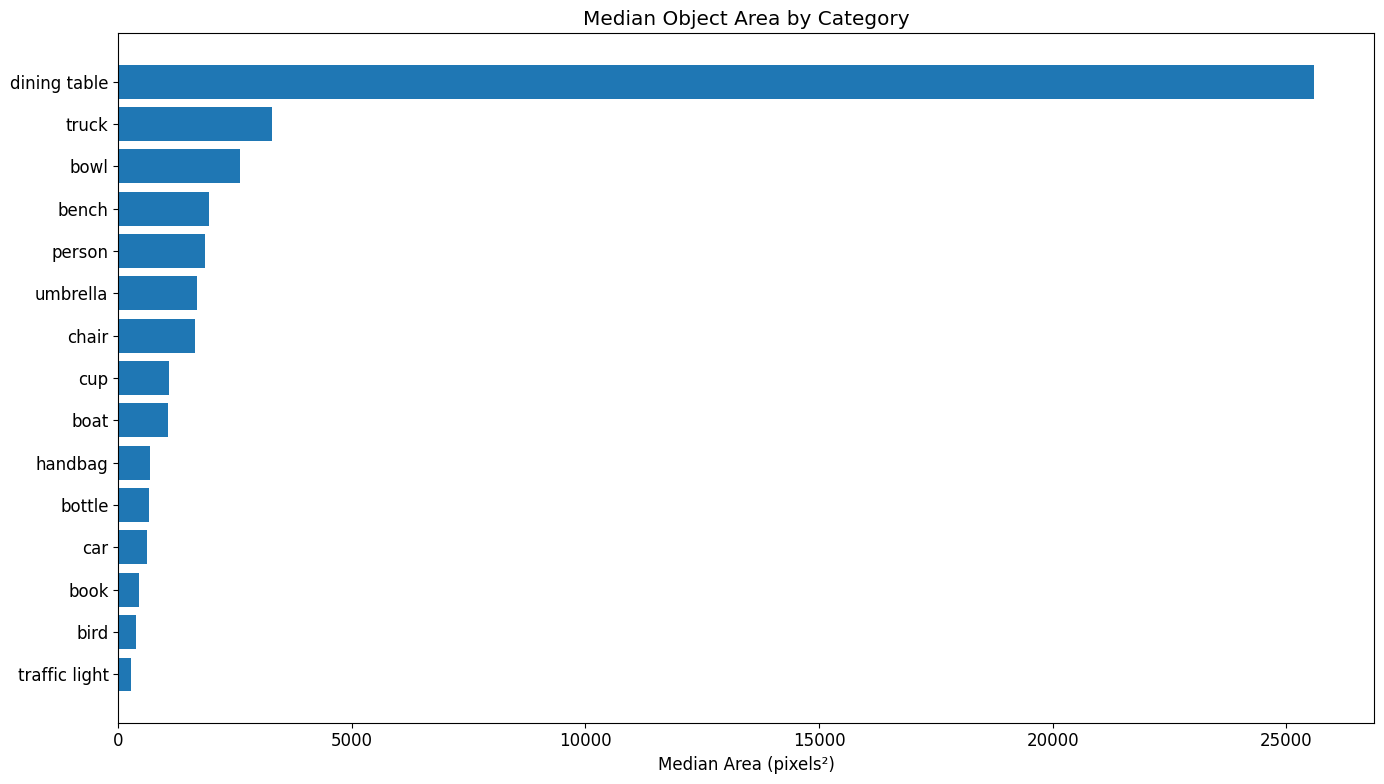

Mean bounding box dimensions: 103.9 x 107.4 pixels
Median bounding box dimensions: 54.1 x 62.3 pixels
Mean object area: 12025.9 pixels²
Median object area: 1697.1 pixels²


In [9]:
# Analyze bounding boxes
def analyze_bounding_boxes(data, categories):
    # Extract bbox information
    bboxes = []
    areas = []
    category_ids = []
    
    for ann in data['annotations']:
        if 'bbox' in ann:
            bboxes.append(ann['bbox'])  # [x, y, width, height]
            areas.append(ann['area'])
            category_ids.append(ann['category_id'])
    
    bboxes = np.array(bboxes)
    areas = np.array(areas)
    
    # Filter out zero or negative areas for log calculation
    valid_areas = areas[areas > 0]
    
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 2, 1)
    if len(valid_areas) > 0:
        plt.hist(np.log10(valid_areas), bins=50, alpha=0.7, color='blue')
        plt.title('Object Area Distribution (log10 scale)')
        plt.xlabel('log10(Area) in pixels²')
        plt.ylabel('Count')
    else:
        plt.text(0.5, 0.5, 'No valid areas to display', 
                horizontalalignment='center', verticalalignment='center')
    
    # Box dimensions
    widths = bboxes[:, 2]
    heights = bboxes[:, 3]
    
    plt.subplot(2, 2, 2)
    plt.hist(widths, bins=50, alpha=0.7, color='green')
    plt.title('Bounding Box Width Distribution')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(2, 2, 3)
    plt.hist(heights, bins=50, alpha=0.7, color='red')
    plt.title('Bounding Box Height Distribution')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(2, 2, 4)
    aspect_ratios = widths / heights
    # Filter out infinite or NaN values
    valid_ratios = aspect_ratios[np.isfinite(aspect_ratios)]
    plt.hist(valid_ratios, bins=50, alpha=0.7, color='purple')
    plt.title('Bounding Box Aspect Ratio (width/height)')
    plt.xlabel('Aspect Ratio')
    plt.ylabel('Count')
    plt.axvline(x=1.0, color='black', linestyle='--', label='Square (1:1)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    
    # Area by category
    plt.figure(figsize=(14, 8))
    category_names = []
    median_areas = []
    
    # Get top 15 categories by count
    top_categories = Counter(category_ids).most_common(15)
    for cat_id, count in top_categories:
        cat_areas = [area for area, cid in zip(areas, category_ids) if cid == cat_id]
        if cat_areas:
            category_names.append(categories[cat_id])
            median_areas.append(np.median(cat_areas))
    
    # Sort by median area
    sorted_indices = np.argsort(median_areas)
    sorted_names = [category_names[i] for i in sorted_indices]
    sorted_areas = [median_areas[i] for i in sorted_indices]
    
    plt.barh(sorted_names, sorted_areas)
    plt.title('Median Object Area by Category')
    plt.xlabel('Median Area (pixels²)')
    plt.tight_layout()
    plt.show()
    
    print(f"Mean bounding box dimensions: {np.mean(widths):.1f} x {np.mean(heights):.1f} pixels")
    print(f"Median bounding box dimensions: {np.median(widths):.1f} x {np.median(heights):.1f} pixels")
    print(f"Mean object area: {np.mean(areas):.1f} pixels²")
    print(f"Median object area: {np.median(areas):.1f} pixels²")

try:
    categories_dict = {cat['id']: cat['name'] for cat in train_data['categories']}
    analyze_bounding_boxes(train_data, categories_dict)
except:
    categories_dict = {cat_id: info['name'] for cat_id, info in train_dataset.categories.items()}
    analyze_bounding_boxes(train_dataset.coco_data, categories_dict)

Could not visualize samples: 'COCODataset' object has no attribute 'idx_to_cat_id'


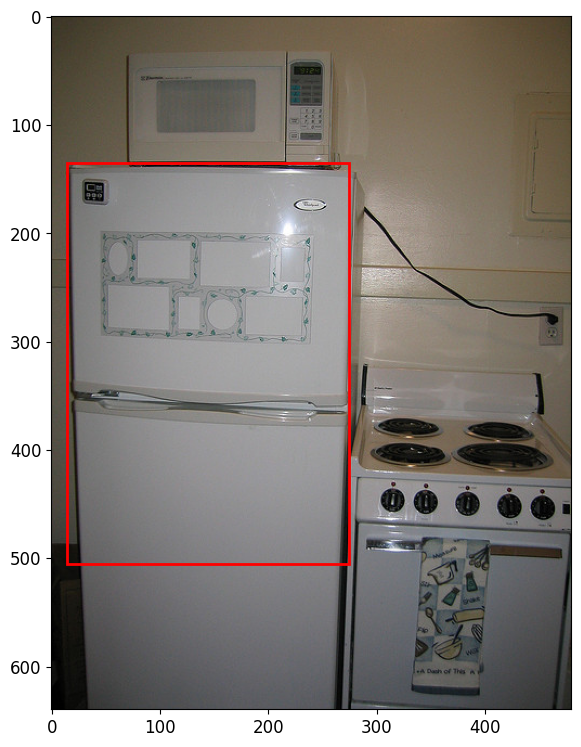

In [19]:
def visualize_samples(dataset, num_samples=5):
    """Visualize random samples from the dataset with annotations"""
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, target = dataset[idx]
        
        if isinstance(image, Image.Image):
            image_np = np.array(image)
        else:
            image_np = image.permute(1, 2, 0).numpy()
            
        fig, ax = plt.subplots(1, figsize=(12, 9))
        ax.imshow(image_np)
        
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()
        
        # Draw bounding boxes and labels
        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            category_name = dataset.get_category_name(label.item())
            ax.text(x1, y1-5, category_name, color='r', fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.7))
        
        ax.set_title(f'Sample {idx}: {len(boxes)} objects')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

try:
    visualize_samples(train_dataset)
except Exception as e:
    print(f"Could not visualize samples: {e}")

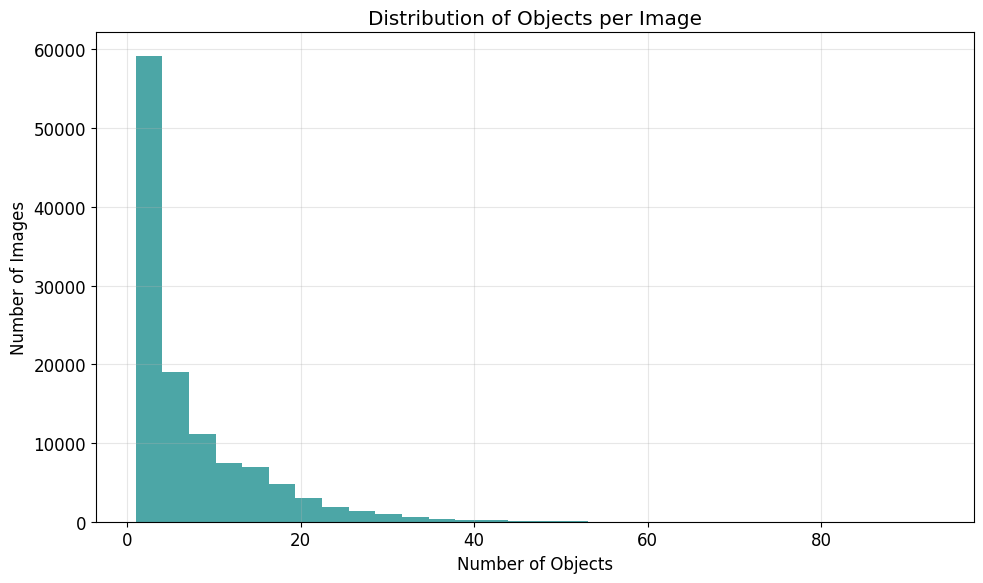

Mean objects per image (non-empty only): 7.33
Median objects per image (non-empty only): 4.00
Maximum objects in one image: 93
Images with no objects: 1021


In [11]:
# Analyze the distribution of objects per image
def analyze_objects_per_image(data):
    img_ids_all = {img['id'] for img in data['images']}
    objects_per_image = Counter()
    for ann in data['annotations']:
        objects_per_image[ann['image_id']] += 1

    covered = set(objects_per_image.keys())
    zero_objs = len(img_ids_all - covered)

    counts = list(objects_per_image.values())
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=30, color='teal', alpha=0.7)
    plt.title('Distribution of Objects per Image')
    plt.xlabel('Number of Objects')
    plt.ylabel('Number of Images')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Mean objects per image (non-empty only): {np.mean(counts):.2f}")
    print(f"Median objects per image (non-empty only): {np.median(counts):.2f}")
    print(f"Maximum objects in one image: {np.max(counts) if counts else 0}")
    print(f"Images with no objects: {zero_objs}")


try:
    analyze_objects_per_image(train_data)
except:
    analyze_objects_per_image(train_dataset.coco_data)

In [12]:
"""
COCO preprocessing utilities.

This block provides small, self-contained helpers used when working with
COCO-format annotations:

- clip_xywh_to_image:  Clip COCO boxes [x, y, w, h] to image bounds and enforce
                       strictly positive width/height.
- filter_small_boxes_xywh:  Remove tiny boxes by minimum area and side length,
                            returning filtered arrays and a boolean keep mask.
- decode_segmentations_to_masks:  Decode polygon or RLE segmentations into a
                                  stack of binary masks with shape [N, H, W].

Note: decode_segmentations_to_masks expects pycocotools RLE objects. If your
dataset contains uncompressed RLEs (counts as a list), convert them with
maskUtils.frPyObjects(...) before decoding.
"""

import numpy as np
from pycocotools import mask as maskUtils

def clip_xywh_to_image(bboxes: np.ndarray, H: int, W: int) -> np.ndarray:
    """Clip COCO boxes [x,y,w,h] to the image of size (H, W)."""
    b = bboxes.copy()
    b[:, 0] = np.clip(b[:, 0], 0, W - 1)
    b[:, 1] = np.clip(b[:, 1], 0, H - 1)
    b[:, 2] = np.clip(b[:, 2], 1e-6, W - b[:, 0])  # width
    b[:, 3] = np.clip(b[:, 3], 1e-6, H - b[:, 1])  # height
    return b

def filter_small_boxes_xywh(
    bboxes: np.ndarray,
    labels: np.ndarray,
    areas: np.ndarray | None = None,
    min_area: float = 16.0,
    min_side: float = 2.0,
):
    """Filter out boxes with too small area or side length (COCO [x,y,w,h])."""
    w = bboxes[:, 2]
    h = bboxes[:, 3]
    keep = (w >= min_side) & (h >= min_side) & ((w * h) >= min_area)
    b = bboxes[keep]
    l = labels[keep]
    a = areas[keep] if areas is not None else None
    return b, l, a, keep

def decode_segmentations_to_masks(segmentations, H: int, W: int) -> np.ndarray:
    """
    Decode COCO segmentations (polygons or RLE) into a [N, H, W] uint8 mask tensor.
    Returns an empty array with shape (0, H, W) if no valid segmentations are found.
    """
    masks = []
    for seg in segmentations:
        if isinstance(seg, list):            # polygons
            rles = maskUtils.frPyObjects(seg, H, W)
            rle = maskUtils.merge(rles)
        elif isinstance(seg, dict) and 'counts' in seg:  # RLE (expects compressed counts)
            rle = seg
        else:
            continue
        m = maskUtils.decode(rle)  # [H, W] {0,1}
        masks.append(m.astype(np.uint8))
    if len(masks) == 0:
        return np.zeros((0, H, W), dtype=np.uint8)
    return np.stack(masks, axis=0)


In [48]:
import random
import numpy as np

"""
Dataset-level clipping & filtering summary.

On a random subset of images, this helper reports:
- how many COCO boxes would be CLIPPED to image bounds by `clip_xywh_to_image`
- how many boxes would be REMOVED by `filter_small_boxes_xywh` given (min_area, min_side)

It prints absolute counts and percentages. Assumes the utilities
`clip_xywh_to_image` and `filter_small_boxes_xywh` are already defined.
"""
def summarize_clip_filter(coco_data, sample_images=200, min_area=16.0, min_side=2.0):
    imgs = coco_data['images']
    anns = coco_data['annotations']

    by_img = {}
    for a in anns:
        by_img.setdefault(a['image_id'], []).append(a)
    img_map = {im['id']: im for im in imgs}

    img_ids = list(by_img.keys())
    random.shuffle(img_ids)
    img_ids = img_ids[:min(sample_images, len(img_ids))]

    total_boxes = 0
    clipped_boxes = 0
    removed_boxes = 0

    for iid in img_ids:
        info = img_map[iid]
        H, W = info['height'], info['width']
        b = np.array([a['bbox'] for a in by_img[iid]], dtype=np.float32)
        if b.size == 0:
            continue
        total_boxes += len(b)

        b0 = b.copy()
        bc = clip_xywh_to_image(b, H, W)
        clipped_boxes += int((np.abs(bc - b0) > 1e-8).any(axis=1).sum())

        # dummy labels to satisfy the filter function signature
        labels_dummy = np.ones((bc.shape[0],), dtype=np.int64)
        _, _, _, keep = filter_small_boxes_xywh(
            bc, labels_dummy, None, min_area=min_area, min_side=min_side
        )
        removed_boxes += int((~keep).sum())

    print("=== Clip & Filter summary ===")
    print(f"Images sampled:         {len(img_ids)}")
    print(f"Total boxes observed:   {total_boxes}")
    print(f"Boxes clipped to image: {clipped_boxes} ({(clipped_boxes/total_boxes*100 if total_boxes else 0):.2f}%)")
    print(f"Boxes removed (small):  {removed_boxes} ({(removed_boxes/total_boxes*100 if total_boxes else 0):.2f}%)")
    
summarize_clip_filter(train_dataset.coco_data, sample_images=500)


=== Clip & Filter summary ===
Images sampled:         500
Total boxes observed:   3640
Boxes clipped to image: 59 (1.62%)
Boxes removed (small):  11 (0.30%)


In [35]:
"""
Transforms & fast image IO for object detection/instance segmentation.

- build_train_transform: Albumentations pipeline for training with geometric
  (LongestMaxSize, PadIfNeeded, Affine) and photometric (brightness/contrast,
  color jitter, blur) augmentations, followed by ImageNet normalization and tensor conversion.
  Bboxes/masks are transformed consistently (COCO bbox format).

- build_val_transform: Deterministic evaluation/preprocessing pipeline
  (resize+pad to stride, normalize, tensor).

- fast_imread_rgb: JPEG-first, high-throughput RGB reader using TurboJPEG if
  available; falls back to OpenCV (imdecode + BGR2RGB). Returns uint8 HWC RGB.
"""

import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from turbojpeg import TurboJPEG  # optional speed-up
    _jpeg = TurboJPEG()
    USE_TURBOJPEG = True
except Exception:
    USE_TURBOJPEG = False

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def build_train_transform(
    img_max: int = 1024,
    stride: int = 32,
    min_area: float = 16.0,
    min_visibility: float = 0.0,
):
    """
    Create the training augmentation pipeline.

    Args:
        img_max: Longest side after resizing.
        stride:  Pad final H/W to be divisible by this value.
        min_area: Minimum bbox area to keep during bbox transforms (COCO units).
        min_visibility: Minimum visible fraction for bboxes to be kept.
    """
    return A.Compose(
        [
            A.LongestMaxSize(max_size=img_max, interpolation=cv2.INTER_LINEAR),
            A.PadIfNeeded(
                min_height=None,
                min_width=None,
                pad_height_divisor=stride,
                pad_width_divisor=stride,
                border_mode=cv2.BORDER_CONSTANT,
                fill=(114, 114, 114),
                fill_mask=0,
            ),
            A.Affine(
                scale=(0.85, 1.15),
                translate_percent=(-0.05, 0.05),
                rotate=(-10, 10),
                shear=(-5, 5),
                border_mode=cv2.BORDER_CONSTANT,
                fill=(114, 114, 114),
                p=0.5,
            ),
            A.RandomBrightnessContrast(p=0.30),
            A.ColorJitter(p=0.20),
            A.GaussianBlur(blur_limit=(3, 5), p=0.15),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(
            format="coco",
            label_fields=["labels", "iscrowd"],
            min_area=min_area,
            min_visibility=min_visibility,
        ),
        strict=True,
    )


def build_val_transform(img_max: int = 1024, stride: int = 32):
    """
    Create the validation/evaluation preprocessing pipeline.

    Args:
        img_max: Longest side after resizing.
        stride:  Pad final H/W to be divisible by this value.
    """
    return A.Compose(
        [
            A.LongestMaxSize(max_size=img_max, interpolation=cv2.INTER_LINEAR),
            A.PadIfNeeded(
                min_height=None,
                min_width=None,
                pad_height_divisor=stride,
                pad_width_divisor=stride,
                border_mode=cv2.BORDER_CONSTANT,
                fill=(114, 114, 114),
                fill_mask=0,
            ),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ],
        bbox_params=A.BboxParams(
            format="coco",
            label_fields=["labels", "iscrowd"],
            min_area=0.0,
            min_visibility=0.0,
        ),
        strict=True,
    )


def fast_imread_rgb(path: str) -> np.ndarray:
    """
    Read an image from disk as RGB uint8 (H, W, 3).

    Uses TurboJPEG when available for faster JPEG decoding; otherwise falls
    back to OpenCV's imdecode and converts BGR→RGB.
    """
    if USE_TURBOJPEG and path.lower().endswith((".jpg", ".jpeg")):
        with open(path, "rb") as f:
            return _jpeg.decode(f.read(), pixel_format=TurboJPEG.TJPF_RGB)
    arr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    return cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)


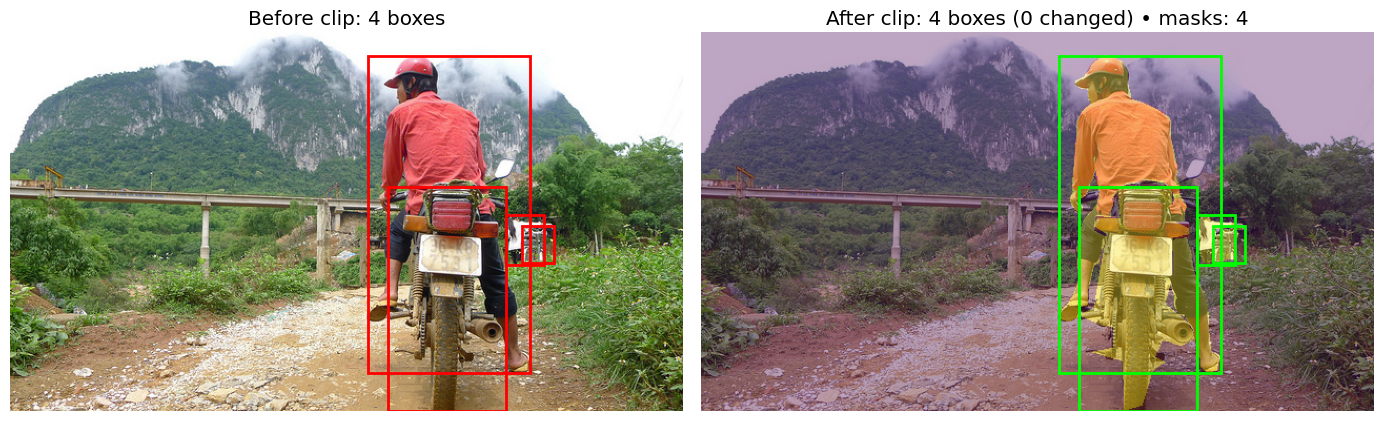

In [47]:
"""
Visualization helper: raw vs. clipped COCO boxes with mask overlay.

Shows a two-panel figure for a given image_id:
- Left: original COCO XYWH boxes (red).
- Right: boxes clipped to image bounds (green) with a semi-transparent overlay
  of decoded instance masks.

Requires the following helpers to be defined elsewhere:
  - fast_imread_rgb(path) -> RGB uint8 image (H, W, 3)
  - decode_segmentations_to_masks(segmentations, H, W) -> [N, H, W] uint8
  - clip_xywh_to_image(bboxes, H, W) -> clipped COCO boxes

Args:
  coco_data: dict with 'images' and 'annotations' in COCO format.
  root_dir:  directory containing the image files.
  image_id:  COCO image id to visualize.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_masks_and_boxes_xywh(coco_data, root_dir, image_id):
    img_map = {im['id']: im for im in coco_data['images']}
    info = img_map[image_id]
    H, W = info['height'], info['width']
    path = os.path.join(root_dir, info['file_name'])

    img = fast_imread_rgb(path)  # HWC RGB
    anns = [a for a in coco_data['annotations'] if a['image_id'] == image_id]
    boxes = np.array([a['bbox'] for a in anns], dtype=np.float32) if len(anns) else np.zeros((0,4), np.float32)
    segs  = [a.get('segmentation', None) for a in anns]

    # Decode masks and clip boxes
    masks = decode_segmentations_to_masks([s for s in segs if s], H, W)
    b_clipped = clip_xywh_to_image(boxes, H, W)
    changed = int((np.abs(b_clipped - boxes) > 1e-8).any(axis=1).sum()) if boxes.size else 0

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    # Left: original XYWH boxes
    ax[0].imshow(img)
    for x, y, w, h in boxes:
        ax[0].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none'))
    ax[0].set_title(f'Before clip: {len(boxes)} boxes')
    ax[0].axis('off')

    # Right: clipped boxes + mask overlay
    ax[1].imshow(img)
    if masks.shape[0] > 0:
        ax[1].imshow(masks.max(axis=0), alpha=0.35)
    for x, y, w, h in b_clipped:
        ax[1].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none'))
    ax[1].set_title(f'After clip: {len(b_clipped)} boxes ({changed} changed) • masks: {masks.shape[0]}')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
    
    
rnd_id = train_dataset.image_ids[0]
visualize_masks_and_boxes_xywh(train_dataset.coco_data, TRAIN_ROOT, rnd_id)


In [36]:
"""
COCO dataset wrapper with on-the-fly transforms (train multiscale or fixed val),
mask decoding, category remapping (COCO ids -> 1..K), post-filtering, and
final XYXY targets.

Requires the following helpers defined elsewhere in your notebook:
  - fast_imread_rgb(path) -> np.ndarray (H, W, 3), RGB uint8
  - build_train_transform(img_max, stride, min_area, min_visibility) -> Albumentations pipeline
  - clip_xywh_to_image(bboxes, H, W) -> np.ndarray [N,4] in COCO XYWH
  - coco_xywh_to_xyxy(boxes_xywh) -> np.ndarray [N,4]
  - clip_xyxy_to_image(boxes_xyxy, H, W) -> np.ndarray [N,4]
  - sanitize_xyxy(...) -> (boxes, labels, iscrowd, masks, keep_mask)
  - decode_segmentations_to_masks(segmentations, H, W) -> np.ndarray [N,H,W] uint8
"""

import os
import random
from typing import Optional, Tuple, Dict, Any
import numpy as np
import torch
from PIL import Image

class COCODatasetWithTransforms(COCODataset):
    """
    COCO-format dataset with Albumentations transforms and optional multi-scale training.

    Args:
        root_dir: Directory containing image files.
        annotation_file: Path to COCO JSON with 'images', 'annotations', 'categories'.
        transform: Albumentations pipeline for evaluation (single fixed transform).
        return_masks: If True, return binary masks in target (when available).
        min_area_post: Minimum bbox area (pixels^2) to keep after transforms.
        min_side_post: Minimum side length (pixels) to keep after transforms.
        multiscale_choices: If provided (e.g., (896,1024,...)), enables train mode with
            a pooled set of train transforms built via `build_train_transform(img_max=s)`.
        stride: Enforce H/W divisible by this value after transforms.
    """
    def __init__(
        self,
        root_dir: str,
        annotation_file: str,
        transform: Optional[Any] = None,
        return_masks: bool = True,
        min_area_post: float = 16.0,
        min_side_post: float = 2.0,
        multiscale_choices: Optional[Tuple[int, ...]] = None,
        stride: int = 32,
    ):
        super().__init__(root_dir, annotation_file, transform=None)
        self.return_masks = return_masks
        self.min_area_post = min_area_post
        self.min_side_post = min_side_post
        self.stride = stride

        # COCO category ids -> contiguous indices 1..K (background is 0)
        self.cat_ids = sorted(list(self.categories.keys()))
        self.cat_id_to_idx = {cid: i + 1 for i, cid in enumerate(self.cat_ids)}
        self.idx_to_cat_id = {i + 1: cid for i, cid in enumerate(self.cat_ids)}

        # Train (multiscale pool) or Val (single transform)
        if multiscale_choices is None:
            self.albu_pool = None
            self.albu = transform  # evaluation pipeline
        else:
            # If a global CFG with thresholds exists, reuse them; otherwise defaults
            try:
                MIN_AREA, MIN_VIS = CFG.min_area, CFG.min_visibility
            except NameError:
                MIN_AREA, MIN_VIS = 16.0, 0.0
            self.albu_pool = {
                s: build_train_transform(
                    img_max=s, stride=self.stride,
                    min_area=MIN_AREA, min_visibility=MIN_VIS
                )
                for s in multiscale_choices
            }
            self.albu = None

    def _choose_transform(self):
        """Randomly pick one transform from the multiscale pool (train mode)."""
        return random.choice(list(self.albu_pool.values()))

    def get_category_name(self, label_idx: int) -> str:
        """Return human-readable category name for a 1..K class index."""
        coco_id = self.idx_to_cat_id[int(label_idx)]
        return self.categories[coco_id]['name']

    def __getitem__(self, idx: int):
        """
        Load image + annotations, apply transforms, post-filter, and return:
            image: Float tensor [C,H,W], normalized by pipeline
            target: dict with keys {boxes (XYXY), labels (1..K), image_id, area, iscrowd, [masks]}
        """
        image_id = self.image_ids[idx]
        img_info = self.images[image_id]
        file_name = img_info['file_name']
        img_path = os.path.join(self.root_dir, file_name)
        image = fast_imread_rgb(img_path)
        H, W = image.shape[:2]

        # Collect per-image annotations
        anns = self.image_annotations[image_id]
        boxes, labels, areas, segmentations, iscrowd = [], [], [], [], []
        for ann in anns:
            if 'bbox' in ann:
                boxes.append(ann['bbox'])                               # COCO XYWH
                labels.append(ann['category_id'])
                areas.append(ann.get('area', ann['bbox'][2] * ann['bbox'][3]))
                segmentations.append(ann.get('segmentation', None))
                iscrowd.append(ann.get('iscrowd', 0))

        boxes   = np.array(boxes,  dtype=np.float32) if boxes   else np.zeros((0, 4), np.float32)
        labels  = np.array(labels, dtype=np.int64)   if labels  else np.zeros((0,),   np.int64)
        areas   = np.array(areas,  dtype=np.float32) if areas   else np.zeros((0,),   np.float32)
        iscrowd = np.array(iscrowd,dtype=np.int64)   if iscrowd else np.zeros((0,),   np.int64)

        # Map COCO category ids -> 1..K
        if len(labels):
            labels = np.array([self.cat_id_to_idx[int(c)] for c in labels], dtype=np.int64)

        # Decode masks (optional)
        masks = []
        if self.return_masks and len(segmentations) > 0:
            masks = decode_segmentations_to_masks(segmentations, H, W)
            masks = [m for m in masks]

        # Initial clipping in XYWH space
        if len(boxes):
            boxes = clip_xywh_to_image(boxes, H, W)

        # Choose transform: train (multiscale pool) or val (single)
        apply_tf = self._choose_transform() if self.albu_pool is not None else self.albu

        if apply_tf is not None:
            # Albumentations expects COCO XYWH bboxes
            transformed = apply_tf(
                image=image,
                bboxes=boxes.tolist(),
                labels=labels.tolist(),
                masks=masks if len(masks) else None,
                iscrowd=iscrowd.tolist(),
            )
            image  = transformed['image']                              # Tensor [C,H,W]
            tb     = np.array(transformed['bboxes'], dtype=np.float32) # XYWH
            tl     = np.array(transformed['labels'], dtype=np.int64)   # 1..K
            tcrowd = np.array(transformed.get('iscrowd', []), dtype=np.int64)
            tm     = transformed.get('masks', None)

            # Post-filter tiny boxes after transforms
            if len(tb):
                tb, tl, _, keep_wh = filter_small_boxes_xywh(
                    tb, tl, None,
                    min_area=self.min_area_post,
                    min_side=self.min_side_post
                )
                if tm is not None and len(tm):
                    tm = [tm[i] for i, k in enumerate(keep_wh) if k]
                if tcrowd.size:
                    tcrowd = tcrowd[keep_wh]

            # Convert to XYXY and clip again to the transformed size
            Ht, Wt = int(image.shape[1]), int(image.shape[2])
            boxes_xyxy = coco_xywh_to_xyxy(tb)
            boxes_xyxy = clip_xyxy_to_image(boxes_xyxy, Ht, Wt)

            # Final sanitation (positive width/height, sync labels/masks/iscrowd)
            boxes_xyxy, tl, tcrowd, tm, keep_final = sanitize_xyxy(
                boxes_xyxy, tl, tcrowd, tm, min_w=1.0, min_h=1.0
            )

            boxes  = boxes_xyxy
            labels = tl
            areas  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

            # Pack masks into tensor if present
            if tm is not None:
                if len(tm):
                    masks = torch.stack([torch.as_tensor(m, dtype=torch.uint8) for m in tm], dim=0)
                else:
                    masks = torch.zeros((0, Ht, Wt), dtype=torch.uint8)
            iscrowd = tcrowd if tcrowd.size else np.zeros((0,), dtype=np.int64)

        else:
            # Evaluation path: no train-time randomness; convert & sanitize
            boxes = coco_xywh_to_xyxy(boxes)
            boxes = clip_xyxy_to_image(boxes, H, W)
            boxes, labels, iscrowd, masks, _ = sanitize_xyxy(
                boxes, labels, iscrowd, masks, min_w=1.0, min_h=1.0
            )
            areas  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            image  = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            if self.return_masks and isinstance(masks, list) and len(masks):
                masks = torch.stack([torch.as_tensor(m, dtype=torch.uint8) for m in masks], dim=0)

        # Build target dict
        target = {
            'boxes':    torch.as_tensor(boxes,  dtype=torch.float32),  # XYXY
            'labels':   torch.as_tensor(labels, dtype=torch.int64),    # 1..K
            'image_id': torch.tensor([image_id], dtype=torch.int64),
            'area':     torch.as_tensor(areas if len(labels) else np.zeros((0,), np.float32)),
            'iscrowd':  torch.as_tensor(iscrowd if len(labels) else np.zeros((0,), np.int64)),
        }
        if self.return_masks:
            if isinstance(masks, np.ndarray):
                masks = torch.from_numpy(masks.astype(np.uint8))
            if masks is None:
                Ht, Wt = int(image.shape[1]), int(image.shape[2])
                masks = torch.zeros((0, Ht, Wt), dtype=torch.uint8)
            target['masks'] = masks

        return image, target


In [15]:
"""
Box geometry utilities for COCO-style pipelines.

- coco_xywh_to_xyxy: Convert COCO [x, y, w, h] boxes to [x1, y1, x2, y2].
- clip_xyxy_to_image: Clip [x1, y1, x2, y2] boxes to image bounds and enforce
  strictly positive width/height.
- sanitize_xyxy: Remove boxes with width/height below thresholds and keep
  label/mask/iscrowd arrays in sync; returns a boolean keep mask as well.
"""

import numpy as np
from typing import List, Optional, Tuple

def coco_xywh_to_xyxy(boxes: np.ndarray) -> np.ndarray:
    """Convert COCO boxes [x, y, w, h] -> [x1, y1, x2, y2]."""
    if boxes.size == 0:
        return boxes.reshape(0, 4)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = x1 + boxes[:, 2]
    y2 = y1 + boxes[:, 3]
    return np.stack([x1, y1, x2, y2], axis=1)

def clip_xyxy_to_image(boxes: np.ndarray, H: int, W: int) -> np.ndarray:
    """
    Clip [x1, y1, x2, y2] boxes to the image size (H, W) and enforce positive
    width/height by nudging x2/y2 to be >= x1/y1 + eps.
    """
    if boxes.size == 0:
        return boxes.reshape(0, 4)
    b = boxes.copy()
    b[:, 0] = np.clip(b[:, 0], 0, W - 1)
    b[:, 1] = np.clip(b[:, 1], 0, H - 1)
    b[:, 2] = np.clip(b[:, 2], 0, W - 1)
    b[:, 3] = np.clip(b[:, 3], 0, H - 1)
    # ensure strictly positive width/height
    b[:, 2] = np.maximum(b[:, 2], b[:, 0] + 1e-6)
    b[:, 3] = np.maximum(b[:, 3], b[:, 1] + 1e-6)
    return b

def sanitize_xyxy(
    boxes_xyxy: np.ndarray,
    labels: np.ndarray,
    iscrowd: Optional[np.ndarray] = None,
    masks: Optional[List[np.ndarray]] = None,
    min_w: float = 1.0,
    min_h: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[np.ndarray], np.ndarray]:
    """
    Final cleanup for [x1, y1, x2, y2] boxes:
      - drop boxes with width < min_w or height < min_h
      - keep labels/iscrowd/masks aligned with the kept indices
      - return a boolean keep mask for downstream use
    """
    if boxes_xyxy.size == 0:
        empty_boxes = boxes_xyxy.reshape(0, 4)
        empty_labels = labels[:0]
        empty_iscrowd = (iscrowd[:0] if iscrowd is not None else np.zeros((0,), np.int64))
        return empty_boxes, empty_labels, empty_iscrowd, [], np.array([], dtype=bool)

    w = boxes_xyxy[:, 2] - boxes_xyxy[:, 0]
    h = boxes_xyxy[:, 3] - boxes_xyxy[:, 1]
    keep = (w >= min_w) & (h >= min_h)

    boxes_xyxy = boxes_xyxy[keep]
    labels = labels[keep] if labels is not None and len(labels) else labels

    if iscrowd is not None and len(iscrowd):
        iscrowd = iscrowd[keep]
    else:
        iscrowd = np.zeros((len(boxes_xyxy),), dtype=np.int64)

    if masks is not None and len(masks):
        masks = [m for i, m in enumerate(masks) if keep[i]]
    else:
        masks = []

    return boxes_xyxy, labels, iscrowd, masks, keep


In [37]:
"""
Datasets & DataLoaders (multiscale + deterministic).

This block wires up:
- A small TrainConfig (img_max choices for multiscale, visibility/area thresholds, seed).
- A collate function that returns lists (compatible with torchvision’s detectors).
- Full determinism setup (global seed, worker_init_fn, torch.Generator).
- Train dataset with a pool of multiscale Albumentations transforms.
- Val dataset with a single deterministic transform.
- DataLoaders with pinned memory and drop_last for train.
- A quick sanity print of one sample.

Prereqs:
  - COCODatasetWithTransforms, build_val_transform
  - TRAIN_ROOT, TRAIN_ANNOTATION, VAL_ROOT, VAL_ANNOTATION
"""

import random
from dataclasses import dataclass
import torch
from torch.utils.data import DataLoader

# 0) Config (create if missing; otherwise extend with defaults)
if 'CFG' not in globals():
    @dataclass
    class TrainConfig:
        img_max_choices: tuple = (896, 1024, 1152, 1280)  # longest side for multiscale train
        min_area: float = 16.0
        min_visibility: float = 0.0
        seed: int = 42
    CFG = TrainConfig()
else:
    # ensure required fields exist
    CFG.img_max_choices = getattr(CFG, 'img_max_choices', (896, 1024, 1152, 1280))
    CFG.min_area        = getattr(CFG, 'min_area', 16.0)
    CFG.min_visibility  = getattr(CFG, 'min_visibility', 0.0)
    CFG.seed            = getattr(CFG, 'seed', 42)

# 1) Collate (returns lists of tensors/targets — standard for torchvision models)
if 'detection_collate' not in globals():
    def detection_collate(batch):
        images, targets = list(zip(*batch))
        return images, targets

# 2) Seeding for determinism (Python, NumPy, Torch, Albumentations)
def seed_everything(seed: int = 42):
    import os, numpy as np, random, torch
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        import albumentations as A
        if hasattr(A, "set_seed"):
            A.set_seed(seed)
    except Exception:
        pass
    return seed

SEED = seed_everything(CFG.seed)

def worker_init_fn(worker_id):
    import numpy as np, random
    s = SEED + worker_id
    np.random.seed(s); random.seed(s)

g = torch.Generator()
g.manual_seed(SEED)

# 3) Datasets
# TRAIN: multiscale via a pool of transforms (random img_max per sample)
train_ds = COCODatasetWithTransforms(
    TRAIN_ROOT, TRAIN_ANNOTATION,
    multiscale_choices=CFG.img_max_choices,
    stride=32,
    return_masks=True,
)

# VAL: single, deterministic transform
val_tf = build_val_transform(img_max=1024, stride=32)
val_ds = COCODatasetWithTransforms(
    VAL_ROOT, VAL_ANNOTATION,
    transform=val_tf,
    return_masks=True,
)

# 4) DataLoaders
BATCH_SIZE = 4
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate,
    pin_memory=True,
    drop_last=True,
    worker_init_fn=worker_init_fn,
    generator=g,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate,
    pin_memory=True,
    worker_init_fn=worker_init_fn,
    generator=g,
)

# 5) Quick sanity-check
img, tgt = train_ds[0]
print("Train sample image shape:", tuple(img.shape), "(C,H,W)")
print("Targets keys:", list(tgt.keys()))


Train sample image shape: (3, 512, 896) (C,H,W)
Targets keys: ['boxes', 'labels', 'image_id', 'area', 'iscrowd', 'masks']


In [38]:
"""
Aspect-ratio bucketing and batch sampler.

- build_aspect_buckets(dataset, bins=(0.75, 1.33)):
    Groups dataset indices into 3 buckets by image aspect ratio (H/W):
      bucket 0: "tall"    if H/W > bins[1]
      bucket 1: "square"  if bins[0] <= H/W <= bins[1]
      bucket 2: "wide"    if H/W < bins[0]
    Expects `dataset.images[img_id]` with 'height' and 'width', and `dataset.image_ids`.

- AspectBucketBatchSampler(buckets, batch_size, shuffle=True, seed=42):
    Iterates batches drawn *within each bucket*, reducing intra-batch shape variance.
    Shuffles per-bucket indices deterministically (by seed) if `shuffle=True`.

Usage:
    buckets = build_aspect_buckets(train_ds, bins=(0.75, 1.33))
    sampler = AspectBucketBatchSampler(buckets, batch_size=4, shuffle=True, seed=42)
    loader  = DataLoader(train_ds, batch_sampler=sampler, collate_fn=detection_collate, ...)
"""

import random
from collections import defaultdict
from torch.utils.data import Sampler

def build_aspect_buckets(dataset, bins=(0.75, 1.33)):
    """
    Build aspect-ratio buckets for a dataset.

    Args:
        dataset: object with `image_ids` and `images` (COCO-style image dicts).
        bins: (low, high) thresholds for H/W separating wide/square/tall.

    Returns:
        dict[int, list[int]] mapping bucket_id -> list of dataset indices.
    """
    buckets = defaultdict(list)
    for idx, img_id in enumerate(dataset.image_ids):
        info = dataset.images[img_id]
        H, W = info['height'], info['width']
        ar = H / max(W, 1)
        # 0 = tall, 1 = square-ish, 2 = wide
        b = 0 if ar > bins[1] else (2 if ar < bins[0] else 1)
        buckets[b].append(idx)
    return buckets


class AspectBucketBatchSampler(Sampler[list]):
    """
    Batch sampler that yields batches from precomputed aspect buckets.

    Args:
        buckets: dict from `build_aspect_buckets`.
        batch_size: number of samples per batch.
        shuffle: shuffle indices within each bucket before batching.
        seed: RNG seed for deterministic shuffling.

    Yields:
        list[int]: a batch of dataset indices from a single bucket.
    """
    def __init__(self, buckets: dict, batch_size: int, shuffle: bool = True, seed: int = 42):
        self.buckets = {k: v[:] for k, v in buckets.items()}
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.seed = seed

    def __iter__(self):
        rng = random.Random(self.seed)
        # local working copies
        local = {k: v[:] for k, v in self.buckets.items()}
        while True:
            made_any = False
            for _, idxs in local.items():
                if self.shuffle:
                    rng.shuffle(idxs)
                while len(idxs) >= self.batch_size:
                    batch = idxs[:self.batch_size]
                    del idxs[:self.batch_size]
                    made_any = True
                    yield batch
            if not made_any:
                break

    def __len__(self):
        return sum(len(v) // self.batch_size for v in self.buckets.values())


In [39]:
"""
Decode COCO segmentations (polygons or RLE) to binary masks.

- Supports:
  * Polygons: list of contour lists -> merged RLE -> decoded mask
  * RLE (compressed): dict with 'counts' as str/bytes -> decoded directly
  * RLE (uncompressed): dict with 'counts' as list -> converted via frPyObjects -> decoded

Returns:
  np.ndarray of shape [N, H, W], dtype=uint8 (0/1). If no valid segmentations,
  returns an empty array with shape (0, H, W).
"""

from typing import Any, List
import numpy as np
from pycocotools import mask as maskUtils

def decode_segmentations_to_masks(segmentations: List[Any], H: int, W: int) -> np.ndarray:
    masks = []
    for seg in segmentations:
        if not seg:
            continue

        # Polygons: list of contours
        if isinstance(seg, list):
            rles = maskUtils.frPyObjects(seg, H, W)   # list of RLEs (one per polygon)
            rle  = maskUtils.merge(rles)              # merge polygons for one instance
            m = maskUtils.decode(rle)                 # (H, W)
            masks.append(m.astype(np.uint8))

        # RLE dict: compressed or uncompressed
        elif isinstance(seg, dict) and 'counts' in seg:
            if isinstance(seg['counts'], list):
                # Uncompressed: convert to proper RLE first
                rle = maskUtils.frPyObjects(seg, H, W)
                m = maskUtils.decode(rle)             # (H, W)
            else:
                # Compressed: decode directly
                m = maskUtils.decode(seg)             # (H, W)
            masks.append(m.astype(np.uint8))

        # Unknown format: skip
        else:
            continue

    if len(masks) == 0:
        return np.zeros((0, H, W), dtype=np.uint8)
    return np.stack(masks, axis=0)


In [40]:
"""
Sanity check for post-processed XYXY boxes and label indices.

For a random subset of samples, this function verifies that:
- all boxes have strictly positive width/height,
- all box coordinates lie within image bounds,
- all labels are within the contiguous range [1..K], where K = number of classes.

It prints a concise summary of counts. Assumes dataset __getitem__ returns:
    (image_tensor [C,H,W], target_dict with 'boxes' (XYXY) and 'labels' (1..K)).
"""

def sanity_xyxy_and_labels(ds, samples: int = 256) -> None:
    K = len(ds.cat_ids)
    if len(ds) == 0:
        print("=== Sanity XYXY & Labels ===")
        print("Dataset is empty.")
        return

    idxs = np.random.choice(len(ds), min(samples, len(ds)), replace=False)

    tot_boxes = 0
    neg_area = 0
    out_of_bounds = 0
    bad_labels = 0

    for i in idxs:
        img, t = ds[i]
        H, W = int(img.shape[1]), int(img.shape[2])

        b = t['boxes'].cpu().numpy() if 'boxes' in t else np.zeros((0, 4), np.float32)
        y = t['labels'].cpu().numpy() if 'labels' in t else np.zeros((0,),   np.int64)

        tot_boxes += len(b)
        if b.size:
            w = b[:, 2] - b[:, 0]
            h = b[:, 3] - b[:, 1]
            neg_area += int(((w <= 0) | (h <= 0)).sum())
            out_of_bounds += int(
                (b[:, 0] < 0).sum() + (b[:, 1] < 0).sum() +
                (b[:, 2] > W - 1).sum() + (b[:, 3] > H - 1).sum()
            )
        if y.size:
            bad_labels += int(((y < 1) | (y > K)).sum())

    print("=== Sanity XYXY & Labels ===")
    print(f"Samples checked: {len(idxs)}")
    print(f"Total boxes:     {tot_boxes}")
    print(f"Non-positive area boxes: {neg_area}")
    print(f"Out-of-bounds coords:    {out_of_bounds}")
    print(f"Labels outside [1..{K}]: {bad_labels}")

sanity_xyxy_and_labels(train_ds, samples=300)


=== Sanity XYXY & Labels ===
Samples checked: 300
Total boxes:     2252
Non-positive area boxes: 0
Out-of-bounds coords:    0
Labels outside [1..80]: 0


In [43]:
"""
Report output image size frequencies and stride alignment.

Samples a subset of dataset items, records (H, W) occurrences after transforms,
and checks whether each size is divisible by a given stride. Prints a frequency
table (most common first) and the number of non–stride-aligned samples.

Args:
    ds:       Dataset whose __getitem__ returns (image_tensor [C,H,W], target_dict).
    samples:  Number of random samples to check (capped at len(ds)).
    stride:   Required divisibility for H and W (e.g., 32).

Notes:
    Useful to validate multiscale pipelines (LongestMaxSize + PadIfNeeded) and
    to decide whether aspect-ratio bucketing or batch padding is needed.
"""

import numpy as np
from collections import Counter

def size_frequencies(ds, samples: int = 400, stride: int = 32) -> None:
    sizes = Counter()
    if len(ds) == 0:
        print("=== Output size frequencies (H×W) ===")
        print("Dataset is empty.")
        return

    idxs = np.random.choice(len(ds), min(samples, len(ds)), replace=False)
    bad_stride = 0

    for i in idxs:
        img, _ = ds[i]
        H, W = int(img.shape[1]), int(img.shape[2])
        sizes[(H, W)] += 1
        if (H % stride != 0) or (W % stride != 0):
            bad_stride += 1

    print("=== Output size frequencies (H×W) ===")
    for (H, W), c in sizes.most_common():
        print(f"{H}×{W}: {c}")
    print(f"Bad stride-aligned samples: {bad_stride} / {len(idxs)}")


size_frequencies(train_ds, samples=300, stride=32)


=== Output size frequencies (H×W) ===
864×1280: 29
672×896: 25
608×896: 24
960×1280: 24
768×1024: 22
864×1152: 20
704×1024: 15
800×1152: 15
1024×704: 12
1280×864: 10
768×1152: 9
1024×1024: 6
1152×864: 6
1280×1280: 5
1024×768: 5
896×672: 4
1280×960: 4
832×1280: 4
896×896: 4
896×1152: 3
832×1152: 3
1152×800: 3
1152×768: 3
928×1152: 2
832×1024: 2
1280×928: 2
896×608: 2
800×1024: 2
1152×1152: 2
928×1280: 2
736×1024: 2
704×1152: 1
928×1024: 1
544×896: 1
576×1152: 1
1024×672: 1
1152×1120: 1
576×1024: 1
896×800: 1
896×736: 1
1216×1280: 1
1024×576: 1
608×1280: 1
736×1280: 1
608×1152: 1
1280×1024: 1
800×1280: 1
864×1024: 1
1152×832: 1
672×1152: 1
1024×1280: 1
1152×960: 1
960×1024: 1
640×1024: 1
672×1024: 1
512×896: 1
1056×1280: 1
896×1024: 1
1152×1280: 1
1280×640: 1
Bad stride-aligned samples: 0 / 300


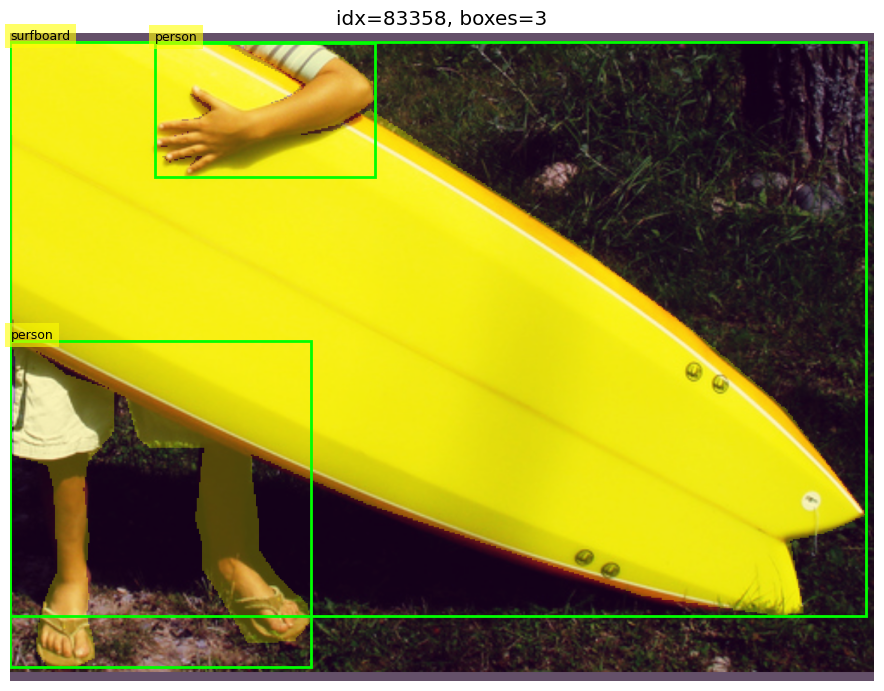

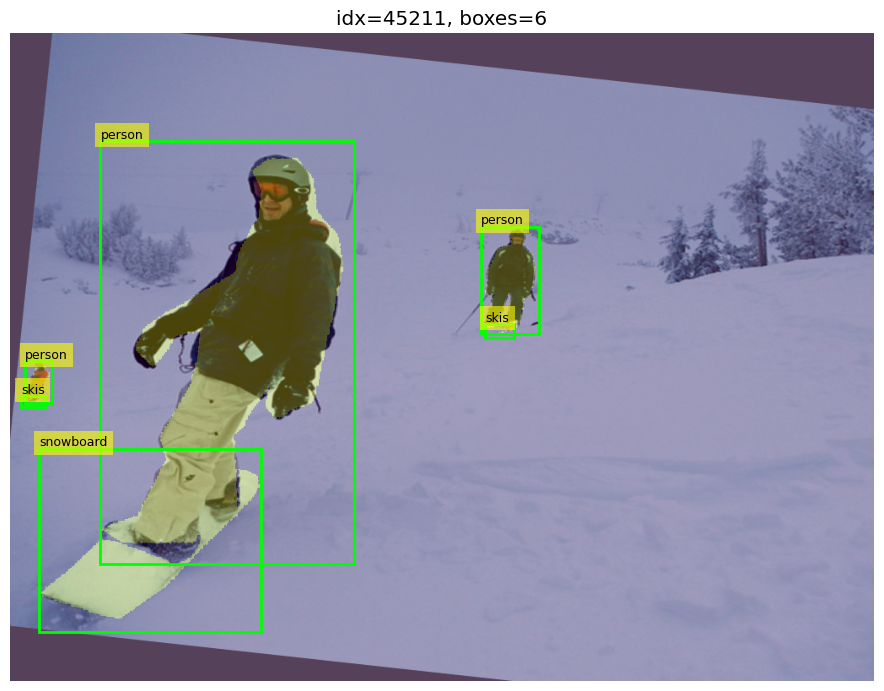

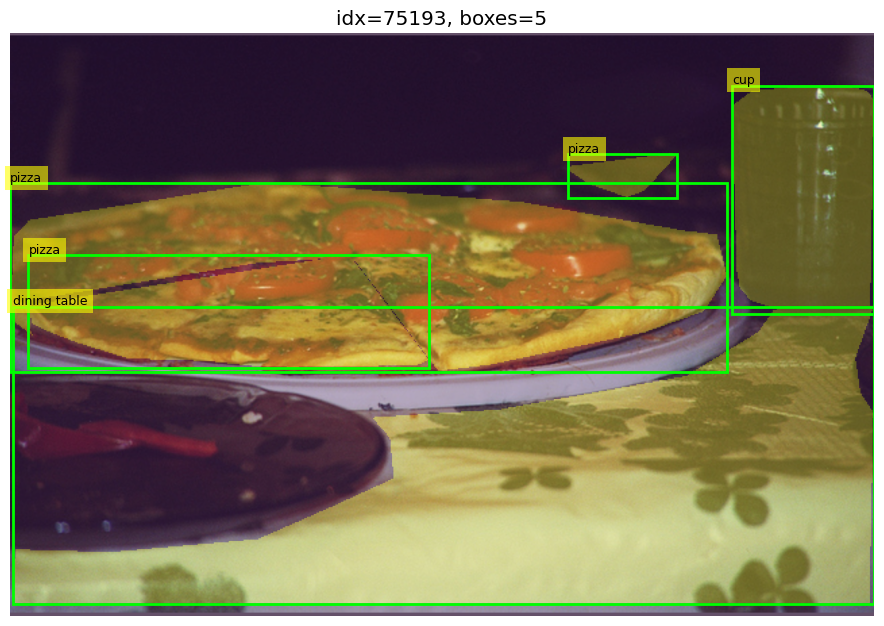

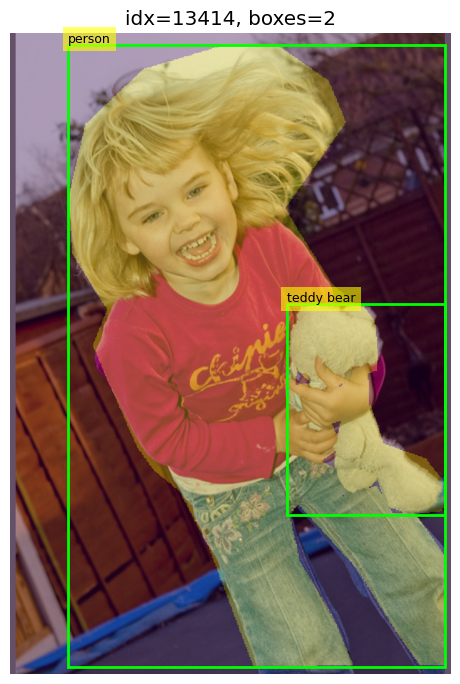

In [44]:
"""
Quick visualization of samples with XYXY boxes (and optional masks).

- _denorm:      Undo mean/std normalization and convert tensor [C,H,W] to RGB float HxW×3.
- visualize_samples_xyxy:
    * Randomly picks N samples from the dataset.
    * Overlays instance masks (if present) with semi-transparent alpha.
    * Draws XYXY boxes and category names (via ds.get_category_name if available).

Assumes dataset __getitem__ returns:
    image:  tensor [C,H,W] already normalized by the pipeline
    target: dict with 'boxes' (XYXY), 'labels' (1..K), and optionally 'masks' (N,H,W)
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def _denorm(img_t, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """De-normalize an image tensor [C,H,W] and return RGB float array in [0,1]."""
    img = img_t.clone().float()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return np.clip(img.permute(1, 2, 0).cpu().numpy(), 0, 1)

def visualize_samples_xyxy(ds, n: int = 4) -> None:
    """Draw random samples with XYXY boxes and optional masks."""
    if len(ds) == 0:
        print("Dataset is empty.")
        return

    idxs = np.random.choice(len(ds), min(n, len(ds)), replace=False)
    for idx in idxs:
        img, t = ds[idx]
        img_np = _denorm(img)

        boxes = t['boxes'].cpu().numpy() if 'boxes' in t else np.zeros((0, 4))
        labels = t['labels'].cpu().numpy() if 'labels' in t else np.zeros((0,))

        masks = t.get('masks', None)
        if masks is not None:
            if hasattr(masks, "cpu"):
                masks_np = masks.cpu().numpy()
            else:
                masks_np = np.asarray(masks)
        else:
            masks_np = None

        fig, ax = plt.subplots(1, 1, figsize=(9, 7))
        ax.imshow(img_np)

        if masks_np is not None and masks_np.shape[0] > 0:
            ax.imshow(masks_np.max(axis=0), alpha=0.3)

        for (x1, y1, x2, y2), lab in zip(boxes, labels):
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='lime', facecolor='none'
                )
            )
            try:
                name = ds.get_category_name(int(lab))
            except Exception:
                name = str(int(lab))
            ax.text(
                x1, max(0, y1 - 3), name, color='black', fontsize=9,
                bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='none')
            )

        ax.set_title(f"idx={idx}, boxes={len(boxes)}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()

visualize_samples_xyxy(train_ds, n=4)


In [45]:
"""
Before/after box retention report.

Randomly samples images and compares:
- BEFORE: number of raw annotation boxes (from COCO JSON).
- AFTER:  number of boxes that survive transforms + post-filtering
          (taken from dataset __getitem__ targets).

Prints absolute counts and the percentage of boxes kept.

Assumptions:
- Dataset exposes `image_ids` (list of COCO image ids) and
  `image_annotations` (dict: image_id -> list of ann dicts).
- `ds[idx]` returns (image, target) where target['boxes'] is a tensor [N,4].
"""

import numpy as np

def boxes_before_after(ds, samples: int = 200) -> None:
    if len(ds) == 0:
        print("=== Boxes kept after post-filter ===")
        print("Dataset is empty.")
        return

    # O(1) lookup for dataset index by image_id
    id_to_idx = {iid: i for i, iid in enumerate(ds.image_ids)}

    img_ids = np.random.choice(ds.image_ids, min(samples, len(ds)), replace=False)
    before = 0
    after  = 0

    for iid in img_ids:
        anns = ds.image_annotations.get(iid, [])
        before += sum(1 for a in anns if 'bbox' in a)

        idx = id_to_idx[iid]
        _, t = ds[idx]
        boxes = t.get('boxes', None)
        after += int(boxes.shape[0]) if boxes is not None else 0

    kept_pct = (after / before * 100) if before else 0.0

    print("=== Boxes kept after post-filter ===")
    print(f"Images sampled: {len(img_ids)}")
    print(f"Before (raw ann boxes): {before}")
    print(f"After  (post-transform): {after}")
    print(f"Kept: {kept_pct:.2f}%")


boxes_before_after(train_ds, samples=200)


=== Boxes kept after post-filter ===
Images sampled: 200
Before (raw ann boxes): 1481
After  (post-transform): 1476
Kept: 99.66%
